# M1 Notebook 03 — Vector Foundations

**Book alignment:** *Mathematics of SRAI*, Chapter 3  
**Notebook ID:** M1_N03  
**Status:** Executed audit candidate — final publication subject to owner approval  
**Random seed:** 42

> Vectors are the native language of modern statistics, machine learning, deep learning, embeddings, optimization, and Decision Intelligence.


## 1. Learning objectives

By the end of this notebook, the reader will be able to:

1. Distinguish scalars, points, and vectors.
2. Perform vector arithmetic and compute common norms.
3. Interpret dot products, cosine similarity, distance, and angles.
4. Compute projections and orthogonal components.
5. Form linear combinations and understand span.
6. Construct an orthonormal basis with Gram–Schmidt.
7. Represent observations, embeddings, and decision states as vectors.


## 2. Prerequisites

- Basic algebra
- Python fundamentals
- M1 Notebook 01
- M1 Notebook 02


## 3. Reproducibility and imports

In [1]:
from srai_math.utils import environment_info, set_seed
from srai_math.algebra import (
    Vector,
    angle_between,
    cosine_similarity,
    cross,
    distance,
    dot,
    gram_schmidt,
    l1_norm,
    l2_norm,
    linear_combination,
    linf_norm,
    normalize,
    project,
    reject,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
set_seed(SEED)
environment_info()


EnvironmentInfo(python='3.12.13', platform='Linux-6.18.35-x86_64-with-glibc2.39', numpy='2.3.5')

## 4. Mathematical intuition

A scalar records magnitude only:

$$
x=5.
$$

A vector records ordered components:

$$
\mathbf{x}=
\begin{bmatrix}
x_1\\
x_2\\
\vdots\\
x_n
\end{bmatrix}.
$$

Depending on context, a vector may represent displacement, an observation, a feature profile, an embedding, a gradient, or the state of a Digital Twin.


## 5. Vector addition and scalar multiplication

For

$$
\mathbf{x}=(x_1,\ldots,x_n),\qquad
\mathbf{y}=(y_1,\ldots,y_n),
$$

$$
\mathbf{x}+\mathbf{y}
=
(x_1+y_1,\ldots,x_n+y_n).
$$

For a scalar $c$,

$$
c\mathbf{x}
=
(cx_1,\ldots,cx_n).
$$


In [2]:
a = Vector.from_iterable([1, 2])
b = Vector.from_iterable([3, 4])

sum_vector = a + b
scaled_vector = 2 * a

sum_vector, scaled_vector


(Vector(values=(4.0, 6.0)), Vector(values=(2.0, 4.0)))

In [3]:
assert sum_vector.values == (4.0, 6.0)
assert scaled_vector.values == (2.0, 4.0)
print("Vector addition and scalar multiplication verified.")


Vector addition and scalar multiplication verified.


## 6. Norms

The $L^1$, $L^2$, and $L^\infty$ norms are

$$
\|\mathbf{x}\|_1=\sum_i |x_i|,
$$

$$
\|\mathbf{x}\|_2=\sqrt{\sum_i x_i^2},
$$

$$
\|\mathbf{x}\|_\infty=\max_i |x_i|.
$$


In [4]:
x = np.array([3.0, -4.0])

norms = {
    "L1": l1_norm(x),
    "L2": l2_norm(x),
    "Linf": linf_norm(x),
}
norms


{'L1': 7.0, 'L2': 5.0, 'Linf': 4.0}

In [5]:
assert norms["L1"] == 7.0
assert np.isclose(norms["L2"], 5.0)
assert norms["Linf"] == 4.0
print("Norm calculations verified.")


Norm calculations verified.


## 7. Distance

Euclidean distance is

$$
d(\mathbf{x},\mathbf{y})
=
\|\mathbf{x}-\mathbf{y}\|_2.
$$


In [6]:
p = np.array([1.0, 2.0])
q = np.array([4.0, 6.0])

d = distance(p, q)
assert np.isclose(d, 5.0)
d


5.0

## 8. Dot product and angle

The dot product is

$$
\mathbf{x}^{\top}\mathbf{y}
=
\sum_i x_i y_i.
$$

The angle $\theta$ satisfies

$$
\cos\theta
=
\frac{\mathbf{x}^{\top}\mathbf{y}}
{\|\mathbf{x}\|_2\|\mathbf{y}\|_2}.
$$


In [7]:
u = np.array([1.0, 0.0])
v = np.array([0.0, 1.0])

dot_uv = dot(u, v)
angle_uv = angle_between(u, v)

assert np.isclose(dot_uv, 0.0)
assert np.isclose(angle_uv, np.pi / 2)

dot_uv, angle_uv


(0.0, 1.5707963267948966)

Orthogonal vectors have zero dot product. In two dimensions, the standard basis vectors

$$
\mathbf{e}_1=(1,0), \qquad \mathbf{e}_2=(0,1)
$$

are orthogonal.


## 9. Cosine similarity

In [8]:
vectors = {
    "same_direction": ([1, 2], [2, 4]),
    "opposite_direction": ([1, 2], [-1, -2]),
    "orthogonal": ([1, 0], [0, 1]),
}

similarities = {
    name: cosine_similarity(a, b)
    for name, (a, b) in vectors.items()
}
similarities


{'same_direction': 0.9999999999999998, 'opposite_direction': -0.9999999999999998, 'orthogonal': 0.0}

In [9]:
assert np.isclose(similarities["same_direction"], 1.0)
assert np.isclose(similarities["opposite_direction"], -1.0)
assert np.isclose(similarities["orthogonal"], 0.0)
print("Cosine similarity verified.")


Cosine similarity verified.


In [10]:
zero = np.zeros(2)
domain_checks = {
    "normalize zero": lambda: normalize(zero),
    "cosine with zero": lambda: cosine_similarity(zero, [1, 0]),
    "projection onto zero": lambda: project([1, 2], zero),
}
for label, operation in domain_checks.items():
    try:
        operation()
    except ValueError:
        print(f"PASS: {label} raises ValueError")
    else:
        raise AssertionError(f"Expected ValueError: {label}")

PASS: normalize zero raises ValueError
PASS: cosine with zero raises ValueError
PASS: projection onto zero raises ValueError


## 10. Projection

The projection of $\mathbf{x}$ onto $\mathbf{u}$ is

$$
\operatorname{proj}_{\mathbf{u}}(\mathbf{x})
=
\frac{\mathbf{x}^{\top}\mathbf{u}}
{\mathbf{u}^{\top}\mathbf{u}}
\mathbf{u}.
$$

The rejection is

$$
\mathbf{x}
-
\operatorname{proj}_{\mathbf{u}}(\mathbf{x}),
$$

which is orthogonal to $\mathbf{u}$.


In [11]:
x = np.array([3.0, 4.0])
u = np.array([1.0, 0.0])

projection = project(x, u)
rejection = reject(x, u)

projection, rejection


(array([3., 0.]), array([0., 4.]))

In [12]:
assert np.allclose(projection, [3.0, 0.0])
assert np.allclose(rejection, [0.0, 4.0])
assert np.isclose(dot(rejection, u), 0.0)
print("Projection and rejection verified.")


Projection and rejection verified.


## 11. Projection visualization

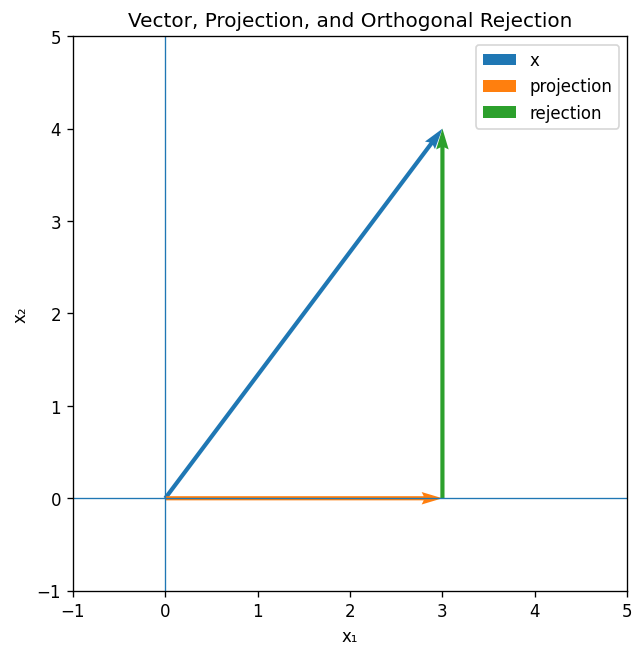

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

ax.quiver(0, 0, x[0], x[1], angles="xy", scale_units="xy", scale=1, color="C0", label="x")
ax.quiver(0, 0, projection[0], projection[1], angles="xy", scale_units="xy", scale=1, color="C1", label="projection")
ax.quiver(projection[0], projection[1], rejection[0], rejection[1], angles="xy", scale_units="xy", scale=1, color="C2", label="rejection")

ax.set_xlim(-1, 5)
ax.set_ylim(-1, 5)
ax.set_aspect("equal")
ax.set_xlabel("x₁")
ax.set_ylabel("x₂")
ax.set_title("Vector, Projection, and Orthogonal Rejection")
ax.legend()
plt.show()


## 12. Linear combinations and span

A linear combination of vectors $\mathbf{v}_1,\ldots,\mathbf{v}_k$ is

$$
c_1\mathbf{v}_1+\cdots+c_k\mathbf{v}_k.
$$

The set of all such combinations is their span.


In [14]:
v1 = np.array([1.0, 0.0])
v2 = np.array([0.0, 1.0])

combination = linear_combination([2, -3], [v1, v2])
assert np.allclose(combination, [2.0, -3.0])
combination


array([ 2., -3.])

## 13. Cross product in three dimensions

In [15]:
i = [1, 0, 0]
j = [0, 1, 0]
k = cross(i, j)

assert np.allclose(k, [0, 0, 1])
assert np.isclose(dot(k, i), 0.0)
assert np.isclose(dot(k, j), 0.0)

k


array([0., 0., 1.])

## 14. Gram–Schmidt orthogonalization

Given linearly independent vectors, Gram–Schmidt constructs an orthonormal basis:

$$
\mathbf{q}_1
=
\frac{\mathbf{v}_1}{\|\mathbf{v}_1\|},
$$

$$
\mathbf{u}_k
=
\mathbf{v}_k
-
\sum_{j=1}^{k-1}
(\mathbf{v}_k^\top\mathbf{q}_j)\mathbf{q}_j,
\qquad
\mathbf{q}_k
=
\frac{\mathbf{u}_k}{\|\mathbf{u}_k\|}.
$$


In [16]:
raw_vectors = [
    [1, 1, 0],
    [1, 0, 1],
    [0, 1, 1],
]

basis = gram_schmidt(raw_vectors)
Q = np.column_stack(basis)

orthonormal_check = Q.T @ Q
orthonormal_check


array([[ 1.00000000e+00,  1.03018891e-16,  7.33073441e-17],
       [ 1.03018891e-16,  1.00000000e+00, -1.03593182e-16],
       [ 7.33073441e-17, -1.03593182e-16,  1.00000000e+00]])

In [17]:
assert np.allclose(orthonormal_check, np.eye(Q.shape[1]), atol=1e-12)
print("Gram–Schmidt orthonormality verified.")


Gram–Schmidt orthonormality verified.


## 15. Statistics interpretation

A statistical dataset with $n$ observations and $p$ variables may be represented as

$$
X=
\begin{bmatrix}
\mathbf{x}_1^\top\\
\vdots\\
\mathbf{x}_n^\top
\end{bmatrix}
\in\mathbb{R}^{n\times p}.
$$

Each row is an observation vector. Each column is a variable vector.


In [18]:
data = pd.DataFrame({
    "rainfall": [400, 500, 600, 700],
    "fertilizer": [20, 25, 35, 40],
    "yield": [2.8, 3.4, 4.1, 4.7],
})

X = data.to_numpy(dtype=float)
X.shape, X


((4, 3), array([[400. ,  20. ,   2.8],
       [500. ,  25. ,   3.4],
       [600. ,  35. ,   4.1],
       [700. ,  40. ,   4.7]]))

## 16. AI interpretation

In AI, vectors represent:

- engineered features;
- token embeddings;
- sentence embeddings;
- image embeddings;
- hidden states;
- gradients;
- attention queries, keys, and values;
- latent variables.

Many AI operations are therefore geometric operations in high-dimensional vector spaces.


## 17. Decision Intelligence case — National state vectors

In [19]:
countries = pd.DataFrame(
    {
        "GDP_growth": [4.8, 4.3, 2.1],
        "inflation": [3.2, 3.6, 8.5],
        "food_production_index": [112, 109, 92],
        "electricity_access": [78, 76, 61],
        "health_capacity": [69, 66, 54],
    },
    index=["State_A", "State_B", "State_C"],
)

countries


         GDP_growth  inflation  ...  electricity_access  health_capacity
State_A         4.8        3.2  ...                  78               69
State_B         4.3        3.6  ...                  76               66
State_C         2.1        8.5  ...                  61               54

[3 rows x 5 columns]

Because the indicators use different units and directions, they must be standardized before geometric comparison. Inflation is also reverse-coded here because lower inflation is treated as preferable for this illustrative comparison.


In [20]:
from sklearn.preprocessing import StandardScaler

policy_data = countries.copy()
policy_data["inflation"] = -policy_data["inflation"]

scaled = StandardScaler().fit_transform(policy_data)
state_vectors = pd.DataFrame(
    scaled,
    index=policy_data.index,
    columns=policy_data.columns,
)

state_vectors


         GDP_growth  inflation  ...  electricity_access  health_capacity
State_A    0.909473   0.788479  ...            0.834812          0.92582
State_B    0.483157   0.622483  ...            0.571187          0.46291
State_C   -1.392630  -1.410962  ...           -1.405999         -1.38873

[3 rows x 5 columns]

In [21]:
a = state_vectors.loc["State_A"].to_numpy()
b = state_vectors.loc["State_B"].to_numpy()
c = state_vectors.loc["State_C"].to_numpy()

comparisons = pd.DataFrame(
    {
        "Euclidean distance": [
            distance(a, b),
            distance(a, c),
            distance(b, c),
        ],
        "Cosine similarity": [
            cosine_similarity(a, b),
            cosine_similarity(a, c),
            cosine_similarity(b, c),
        ],
    },
    index=["A–B", "A–C", "B–C"],
)

comparisons


     Euclidean distance  Cosine similarity
A–B            0.780467           0.986259
A–C            5.066872          -0.997989
B–C            4.326393          -0.994748

### Scaling and weighting sensitivity

A geometric comparison is conditional on preprocessing. The following check compares raw, standardized and deliberately reweighted distances. It demonstrates that numerical geometry changes when units or policy weights change; those choices must therefore be documented before interpretation.


In [22]:
pairs = [("A–B", "State_A", "State_B"), ("A–C", "State_A", "State_C"), ("B–C", "State_B", "State_C")]
raw_vectors = policy_data.to_numpy(dtype=float)
weighted_vectors = state_vectors.to_numpy(dtype=float).copy()
weighted_vectors[:, 1] *= 5.0  # illustrative inflation weight
rows = []
for label, left, right in pairs:
    i, j = state_vectors.index.get_loc(left), state_vectors.index.get_loc(right)
    rows.append({
        "Pair": label,
        "Raw distance": distance(raw_vectors[i], raw_vectors[j]),
        "Standardized distance": distance(state_vectors.iloc[i], state_vectors.iloc[j]),
        "Reweighted distance": distance(weighted_vectors[i], weighted_vectors[j]),
    })
sensitivity = pd.DataFrame(rows).set_index("Pair")
assert not np.allclose(sensitivity["Raw distance"], sensitivity["Standardized distance"])
assert not np.allclose(sensitivity["Standardized distance"], sensitivity["Reweighted distance"])
sensitivity.round(6)

      Raw distance  Standardized distance  Reweighted distance
Pair                                                          
A–B       4.733920               0.780467             1.127137
A–C      30.812011               5.066872            11.906898
B–C      26.207823               4.326393            10.860725

### Interpretation

In this synthetic example, geometric similarity describes similarity in standardized indicator profiles. It does not by itself establish policy equivalence, causal similarity, or welfare superiority. Indicator selection and scaling are substantive modeling choices.


## 18. Engineering notes

- Dense vectors are efficient for moderate-dimensional numerical work.
- Sparse vectors are preferable when most components are zero.
- Vectorized NumPy operations are faster than Python loops.
- Floating-point comparisons should use tolerances.
- High-dimensional Euclidean distances may become less discriminating.
- Normalization and standardization can materially change similarity results.
- Cosine similarity ignores magnitude and focuses on direction.


## 19. Common errors

- Confusing a point with a displacement vector.
- Normalizing the zero vector.
- Comparing heterogeneous indicators without scaling.
- Interpreting cosine similarity as causation or policy equivalence.
- Assuming all norms encode the same practical meaning.
- Applying Euclidean distance blindly in high dimensions.


## 20. Exercises

### Level A

1. Explain the difference between magnitude and direction.
2. Interpret orthogonality geometrically.
3. Explain why cosine similarity is scale-invariant.

### Level B

1. Prove the projection rejection is orthogonal to the projection direction.
2. Verify the Cauchy–Schwarz inequality numerically for random vectors.
3. Derive the angle formula from the dot product.

### Level C

1. Implement cosine similarity without NumPy.
2. Implement Gram–Schmidt and compare with the SDK version.
3. Benchmark Python loops against NumPy vectorization.

### Capstone

Construct a multi-sector Decision State Vector for agriculture, health, energy, and fiscal stability. Compare alternative policy scenarios after documenting scaling, weighting, uncertainty, and interpretation assumptions.


## 21. Research extensions

- Mahalanobis geometry
- Sparse embeddings
- High-dimensional concentration
- Kernel feature spaces
- Policy manifolds
- Uncertainty-aware decision vectors
- Dynamic state vectors for Digital Twins


## 22. Key insight

Vectors transform complex observations into geometry. Once information becomes a vector, it can be compared, projected, normalized, optimized, embedded, and learned from. This makes vector mathematics a foundational language for Statistics, AI, Digital Twins, and Decision Intelligence.
